print('Hello, World!)

In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path
from mpl_toolkits.mplot3d import Axes3D
import numpy as np # Used for calculating percentiles
import sys

# --- Configuration ---
CSV_FILENAME = 'order_processing_times.csv'
FIGURES_DIR_NAME = 'figures'

# Set Matplotlib style for better visuals
plt.style.use('ggplot')

# Determine the directory where the script/notebook is located
# Use Path(__file__) if running as a .py script, or Path.cwd() if in a notebook
try:
    # If running from a standard Python script
    SCRIPT_DIR = Path(__file__).parent
except NameError:
    # If running inside a Jupyter Notebook or interactive shell
    SCRIPT_DIR = Path.cwd()

# Define the absolute paths for input data and output figures
CSV_PATH = SCRIPT_DIR / CSV_FILENAME
FIGURES_PATH = SCRIPT_DIR.parent / FIGURES_DIR_NAME

# Create figures directory if it doesn't exist
FIGURES_PATH.mkdir(exist_ok=True)

print(f"Current Directory (CWD): {Path.cwd()}")
print(f"Looking for data file at: {CSV_PATH.resolve()}")
print(f"Saving figures to directory: {FIGURES_PATH.resolve()}")

Current Directory (CWD): c:\Users\gunne\Desktop\Development\contri-to-hft\Limit-Order-Book\Process_Orders
Looking for data file at: C:\Users\gunne\Desktop\Development\contri-to-hft\Limit-Order-Book\Process_Orders\order_processing_times.csv
Saving figures to directory: C:\Users\gunne\Desktop\Development\contri-to-hft\Limit-Order-Book\figures


In [6]:
def plot_order_distribution(orderTypes, figures_path: Path):
    """Create a pie chart of the distribution of order types."""
    order_type_counts = orderTypes.value_counts()
    
    plt.figure(figsize=(8, 8))
    plt.pie(
        order_type_counts, 
        labels=order_type_counts.index, 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=plt.cm.Set3.colors
    )
    plt.title('Distribution of Order Types', fontsize=16)
    plt.tight_layout()
    plt.savefig(figures_path / 'OrderTypes.png')
    plt.show()

def plot_latency_histogram(times, average_time, figures_path: Path):
    """Create a histogram of the order latencies."""
    # Filter out extreme outliers for better visualization (up to 4000ns)
    filtered_times = times[times <= 4000]
    
    plt.figure(figsize=(10, 6))
    plt.hist(filtered_times, bins=40, color='#4CAF50', edgecolor='black')
    plt.axvline(average_time, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {average_time:.1f} ns')
    
    plt.title(f'Order Latency Histogram (Filtered) - Mean={average_time:.1f}ns', fontsize=16)
    plt.xlabel('Latency (ns)')
    plt.ylabel('Number of Orders')
    plt.legend()
    plt.savefig(figures_path / 'LatencyHistogram.png')
    plt.show()

def plot_latency_by_type(df, figures_path: Path):
    """Create a bar chart with percentile error bars for latency by order type."""
    excluded_order_types = ['Market', 'AddMarketLimit']
    filtered_df = df[~df['Order Type'].isin(excluded_order_types)]

    stats = filtered_df.groupby('Order Type')['Times'].agg(
        mean='mean',
        p15=lambda x: x.quantile(0.15),
        p85=lambda x: x.quantile(0.85)
    ).reset_index()
    
    stats['error_lower'] = stats['mean'] - stats['p15']
    stats['error_upper'] = stats['p85'] - stats['mean']
    stats = stats.sort_values(by='mean')

    plt.figure(figsize=(12, 6))
    plt.bar(
        stats['Order Type'], 
        stats['mean'], 
        yerr=[stats['error_lower'], stats['error_upper']], 
        capsize=5, 
        color='#2196F3', 
        edgecolor='black'
    )
    plt.title('Mean Latency by Order Type (15th/85th Percentile Error Bars)', fontsize=16)
    plt.xlabel('Order Type')
    plt.ylabel('Mean Latency (ns)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(figures_path / 'OrderTypeLatencies.png')
    plt.show()

def plot_latency_by_trades(df, figures_path: Path):
    """Create a bar chart for latency by the number of executed orders."""
    market_df = df[df['Order Type'].isin(['Market', 'AddMarketLimit'])]

    stats = market_df.groupby('Executed Orders')['Times'].agg(mean='mean', count='count').reset_index()
    stats_filtered = stats[stats['count'] >= 5]
    
    plt.figure(figsize=(12, 6))
    plt.bar(
        stats_filtered['Executed Orders'], 
        stats_filtered['mean'], 
        color='#FFC107', 
        edgecolor='black'
    )
    plt.title('Mean Latency by Number of Trades per Order', fontsize=16)
    plt.xlabel('Number of Trades per Order (Min 5 Samples)')
    plt.ylabel('Mean Latency (ns)')
    plt.tight_layout()
    plt.savefig(figures_path / 'ExecutedOrders.png')
    plt.show()

def plot_latency_by_balances(df, figures_path: Path):
    """Create a bar chart for latency by the number of AVL tree balances."""
    balance_df = df[df['AVL Tree Balances'] != 0]

    stats = balance_df.groupby('AVL Tree Balances')['Times'].agg(mean='mean', count='count').reset_index()
    stats_filtered = stats[stats['count'] >= 5]

    plt.figure(figsize=(12, 6))
    plt.bar(
        stats_filtered['AVL Tree Balances'], 
        stats_filtered['mean'], 
        color='#9C27B0', 
        edgecolor='black'
    )
    plt.title('Mean Latency by Number of AVL Tree Balances', fontsize=16)
    plt.xlabel('Number of AVL Tree Balances (Min 5 Samples)')
    plt.ylabel('Mean Latency (ns)')
    plt.tight_layout()
    plt.savefig(figures_path / 'AVLTreeBalances.png')
    plt.show()

def plot_latency_3d(df, figures_path: Path):
    """Create a 3D bar chart for latency by trades and AVL balances."""
    market_df = df[df['Order Type'].isin(['Market', 'AddMarketLimit'])]
    
    stats = market_df.groupby(['Executed Orders', 'AVL Tree Balances'])['Times'].agg(mean='mean', count='count').reset_index()
    stats_filtered = stats[stats['count'] >= 5]
    
    x = stats_filtered['Executed Orders']
    y = stats_filtered['AVL Tree Balances']
    z = stats_filtered['mean']
    
    # Use max() to determine the offset for 3D bar positioning
    x_max = x.max() if not x.empty else 0
    x_offset = x - 0.5 # Center the bar
    y_offset = y - 0.5

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Create 3D bar chart for latency for number of orders executed and avl tree balances
    ax.bar3d(
        x_offset, y_offset, 0, # x, y, z
        0.8, 0.8, z,          # dx, dy, dz
        color='#F44336'
    )
    
    ax.set_xlabel('Number of Trades per Order')
    ax.set_ylabel('AVL Tree Balances')
    ax.set_zlabel('Mean Latency (ns)')
    ax.set_title('Mean Latency by Number of Trades and AVL Tree Balances', fontsize=16)
    
    ax.view_init(elev=20., azim=-45) # Adjust viewing angle
    plt.tight_layout()
    plt.savefig(figures_path / '3D_Latency.png')
    plt.show()

def plot_latency_box_plot(df, figures_path: Path):
    """
    Creates a box plot to visualize the latency distribution (median, IQR, outliers) 
    for each order type, excluding extreme outliers for clarity.
    """
    # Exclude Market and AddMarketLimit as they often have very high latency due to trades
    excluded_order_types = ['Market', 'AddMarketLimit']
    filtered_df = df[~df['Order Type'].isin(excluded_order_types)]
    
    # Filter out extreme overall outliers (e.g., above 99th percentile or 10,000ns)
    # This keeps the plot readable by focusing on the majority of data
    max_time_for_plot = min(filtered_df['Times'].quantile(0.995), 10000)
    filtered_df = filtered_df[filtered_df['Times'] <= max_time_for_plot]
    
    plt.figure(figsize=(14, 7))
    
    # The 'Times' column is plotted against the 'Order Type' column
    filtered_df.boxplot(column='Times', by='Order Type', rot=45, grid=False, 
                        patch_artist=True, medianprops=dict(color='red', linewidth=2))
    
    plt.suptitle('') # Suppress the default Pandas title
    plt.title(f'Order Latency Distribution (Box Plot) up to {int(max_time_for_plot)}ns', fontsize=16)
    plt.xlabel('Order Type')
    plt.ylabel('Latency (ns)')
    plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout for suptitle/title
    plt.savefig(figures_path / 'LatencyBoxPlot.png')
    plt.show()

def plot_latency_over_time(df, figures_path: Path):
    """
    Creates a scatter plot to visualize latency progression over the course of the simulation 
    (assuming rows are chronological).
    """
    # Create an 'Order Index' to represent the time/sequence of orders
    df['Order Index'] = df.index
    
    # Filter out extreme outliers for a clearer scatter plot visualization
    max_time_for_plot = df['Times'].quantile(0.99)
    plot_df = df[df['Times'] <= max_time_for_plot]
    
    plt.figure(figsize=(12, 6))
    plt.scatter(plot_df['Order Index'], plot_df['Times'], 
                s=1, alpha=0.6, color='darkorange', label=f'Latency (Filtered to P99)')
    
    # Calculate and plot a rolling mean to visualize trends
    window_size = 500
    if len(plot_df) >= window_size:
        rolling_mean = plot_df['Times'].rolling(window=window_size).mean()
        plt.plot(plot_df['Order Index'], rolling_mean, color='blue', 
                 linewidth=2, label=f'{window_size}-Order Rolling Mean')
        
    plt.title('Order Latency vs. Order Sequence (Order Flow)', fontsize=16)
    plt.xlabel('Order Index (Time/Sequence)')
    plt.ylabel('Latency (ns)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(figures_path / 'LatencyOverTime.png')
    plt.show()

In [8]:
def create_bar_chart_from_csv(csv_path: Path, figures_path: Path):
    """Loads CSV data, prints metrics, and generates visualizations."""
    
    # --- Data Loading and Error Handling ---
    try:
        df = pd.read_csv(
            csv_path,
            header=None,
            names=['Order Type', 'Times', 'Executed Orders', 'AVL Tree Balances']
        )
    except FileNotFoundError:
        print(f"\n❌ ERROR: Data file not found at: {csv_path}")
        print("Please ensure your C++ program has run and generated the performance data.")
        return
    except Exception as e:
        print(f"\n❌ An error occurred while reading the CSV: {e}")
        return

    # Basic validation
    if not all(col in df.columns for col in ['Times', 'Order Type']):
        raise ValueError("CSV structure error: Missing 'Times' or 'Order Type' columns.")

    # Extract key data
    times = df['Times']
    orderTypes = df.loc[df['Order Type'].notna(), 'Order Type']
    
    # --- Print Summary Metrics (Enhanced) ---
    average_time = times.mean()
    median_time = times.median()
    latency_p99 = times.quantile(0.99)
    trades_count = df['Executed Orders'].sum()
    balances_count = df['AVL Tree Balances'].sum()
    total_orders = len(df)
    
    print("\n--- 🔬 Performance Summary ---")
    print(f"📊 Total Orders Processed: {total_orders:,}")
    print(f"📈 Total Trades Executed: {trades_count:,}")
    print(f"🌳 Total AVL Rebalances: {balances_count:,}")
    print("-" * 30)
    print(f"⏱️ Overall Mean Latency: {average_time:.2f} ns")
    print(f"🥇 Overall Median Latency (P50): {median_time:.2f} ns")
    print(f"🚨 99th Percentile Latency (P99): {latency_p99:.2f} ns (Max outlier time)")
    print(f"🚀 Estimated Throughput: {10**9 / average_time:,.0f} orders/s")
    
    # --- Plotting Functions Call ---
    plot_order_distribution(orderTypes, figures_path)
    plot_latency_histogram(times, average_time, figures_path)
    plot_latency_by_type(df, figures_path)
    
    # --- NEW FUNCTION CALLS ---
    plot_latency_box_plot(df, figures_path)
    plot_latency_over_time(df, figures_path)
    # ---------------------------
    
    plot_latency_by_trades(df, figures_path)
    plot_latency_by_balances(df, figures_path)
    plot_latency_3d(df, figures_path)

    print("\n✅ All charts generated and saved successfully.")


--- 🔬 Performance Summary ---
📊 Total Orders Processed: 5,000,000
📈 Total Trades Executed: 845,242
🌳 Total AVL Rebalances: 252,504
------------------------------
⏱️ Overall Mean Latency: 713.12 ns
🥇 Overall Median Latency (P50): 500.00 ns
🚨 99th Percentile Latency (P99): 4200.00 ns (Max outlier time)
🚀 Estimated Throughput: 1,402,280 orders/s


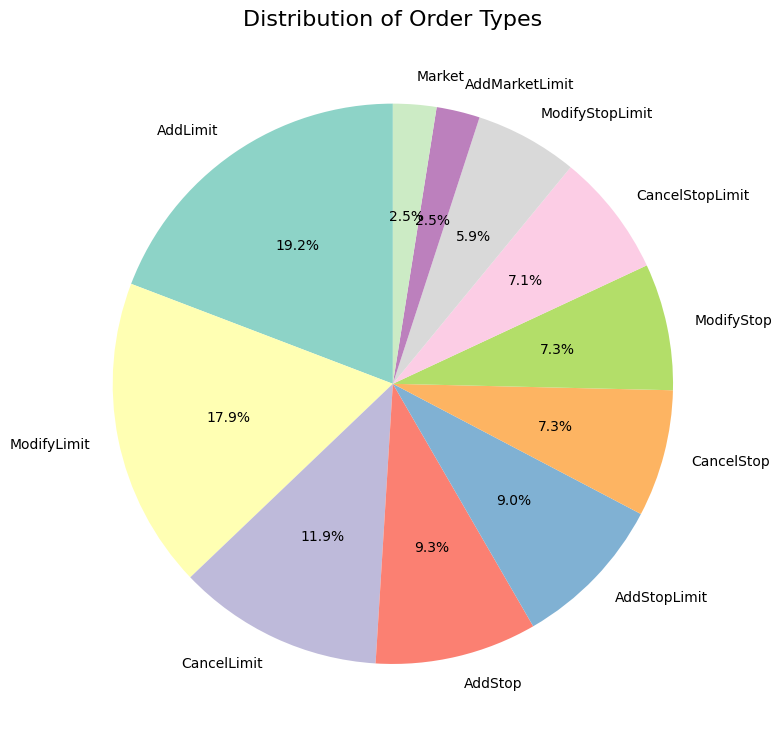

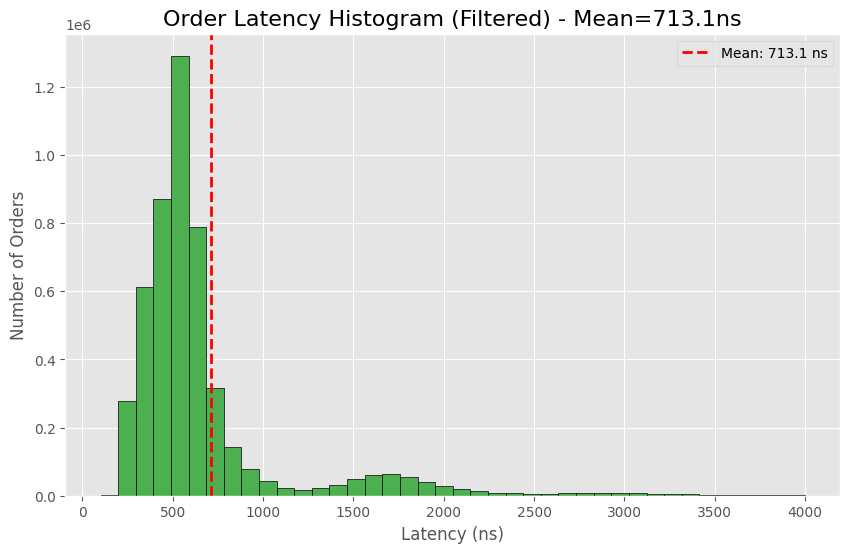

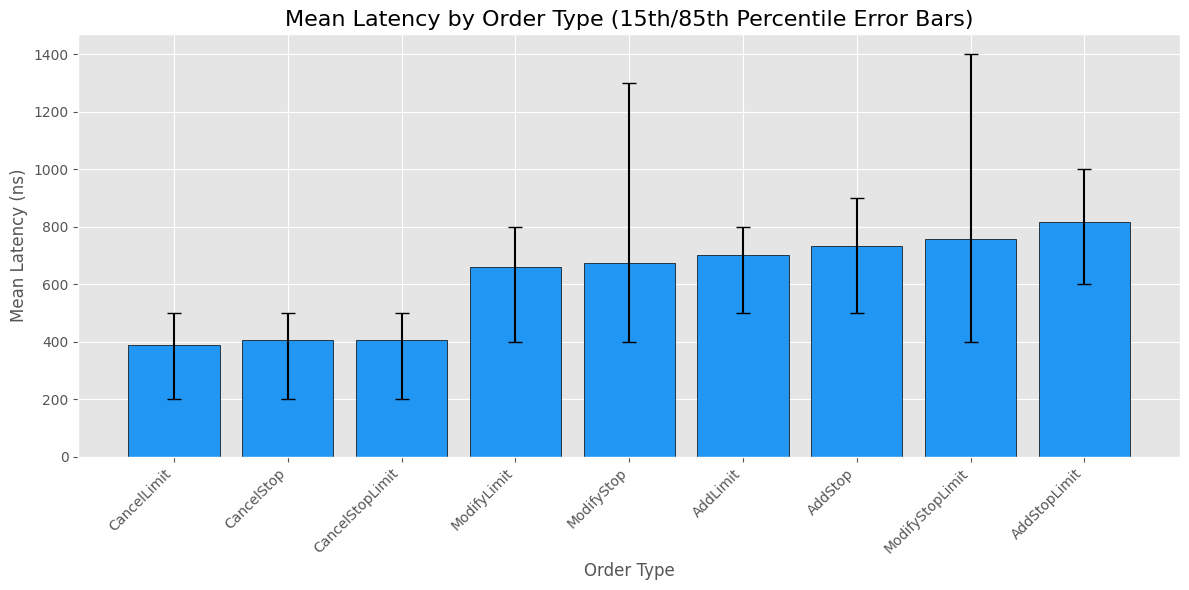

<Figure size 1400x700 with 0 Axes>

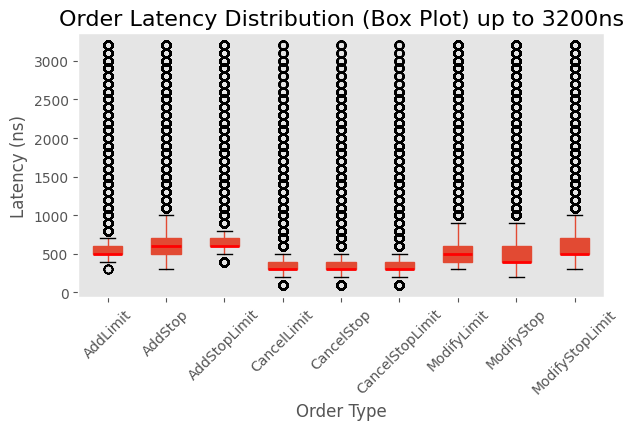

C:\Users\gunne\AppData\Local\Temp\ipykernel_24000\1186991865.py:200: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\gunne\AppData\Local\Temp\ipykernel_24000\1186991865.py:201: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(figures_path / 'LatencyOverTime.png')
C:\Users\gunne\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


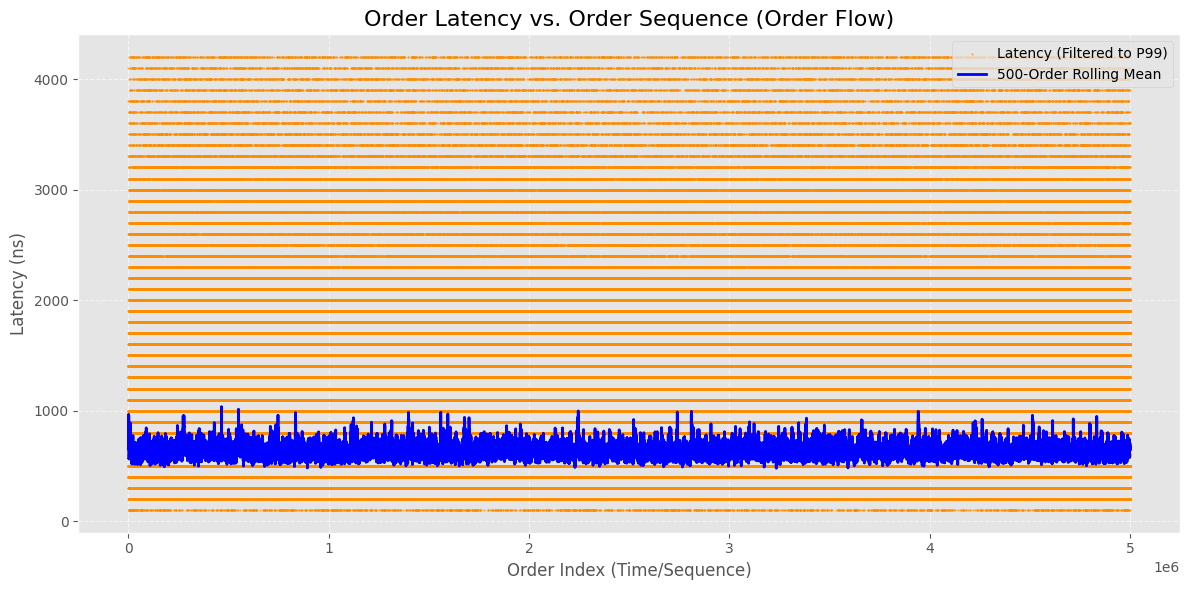

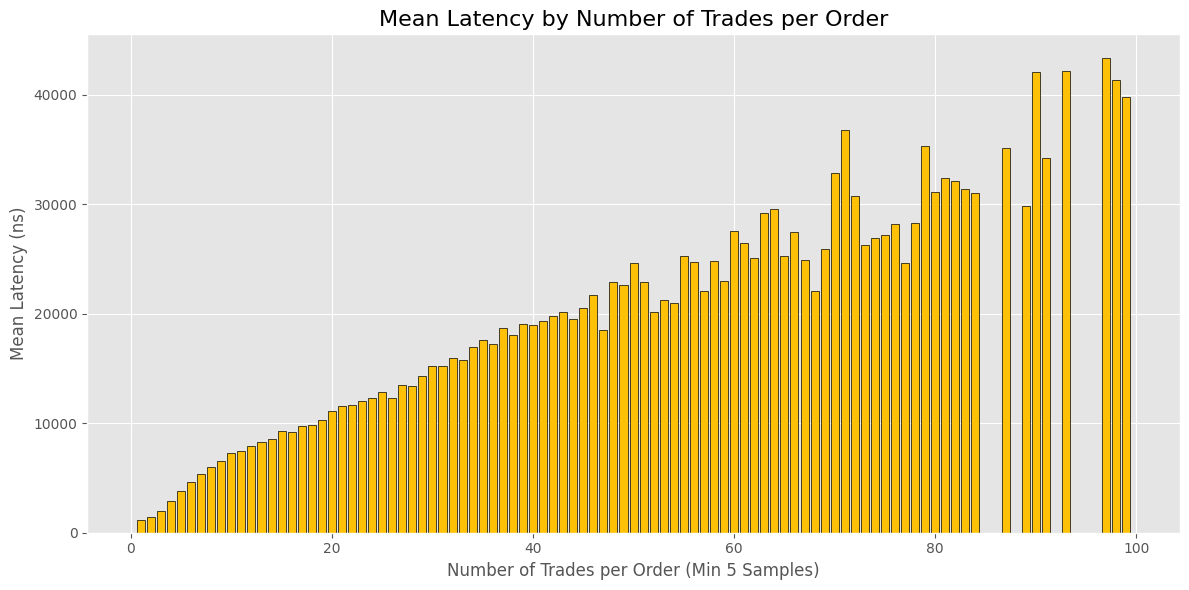

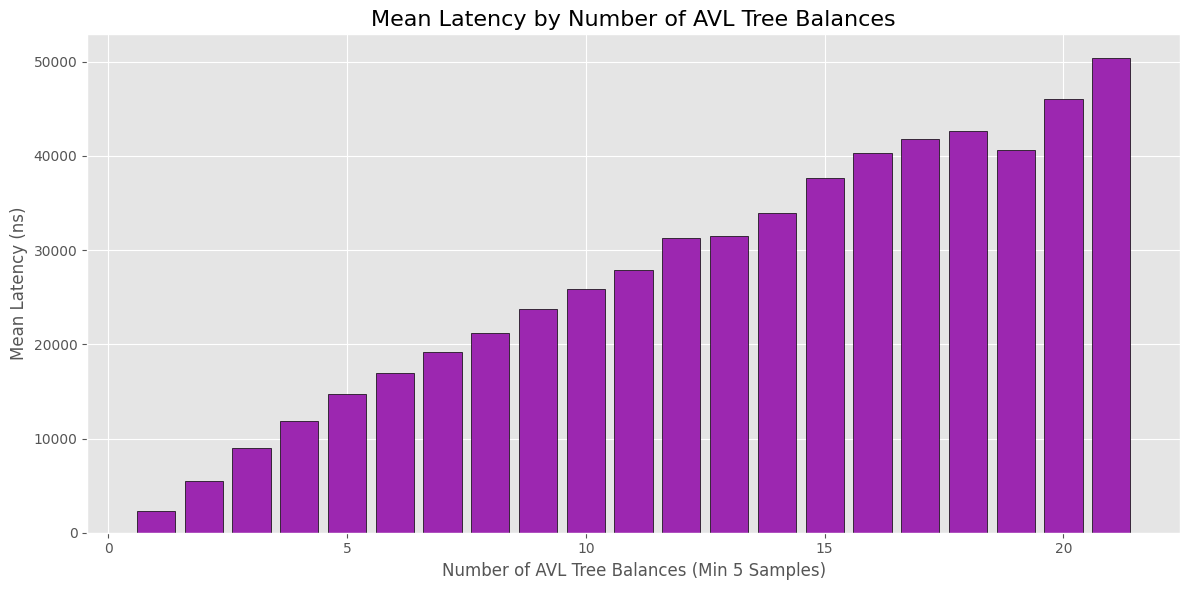

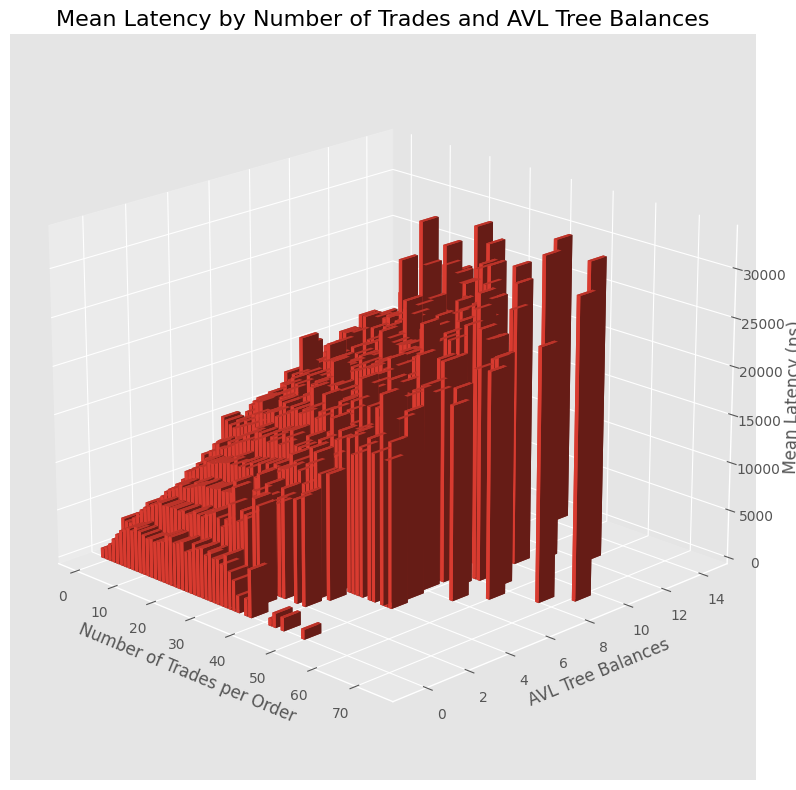


✅ All charts generated and saved successfully.


In [9]:
create_bar_chart_from_csv(CSV_PATH, FIGURES_PATH)